Function Transformers
- A FunctionTransformer is a utility in scikit-learn that lets you apply a custom function to your data as part of a preprocessing pipeline.
- It helps us to apply custom transformer on data and make the data nomally distributed

### **❓ Why do we use FunctionTransformer?**

We use it when:

- Built-in transformers (like StandardScaler, OneHotEncoder) are not enough

- We want to apply custom logic to features

- We want to keep clean, reusable, pipeline-friendly code

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

**Function Transformer**
- Log Transformer
- Reciprocal Transformer
- square / squareroot Transformer

In [ ]:
data = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [ ]:
data.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
data.isna().sum()

,0
Survived,0
Age,177
Fare,0


In [ ]:
data['Age'].fillna(data['Age'].mean(),inplace=True)

/tmp/ipython-input-1761542025.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(),inplace=True)


In [ ]:
x = data[['Age','Fare']]
y = data['Survived']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

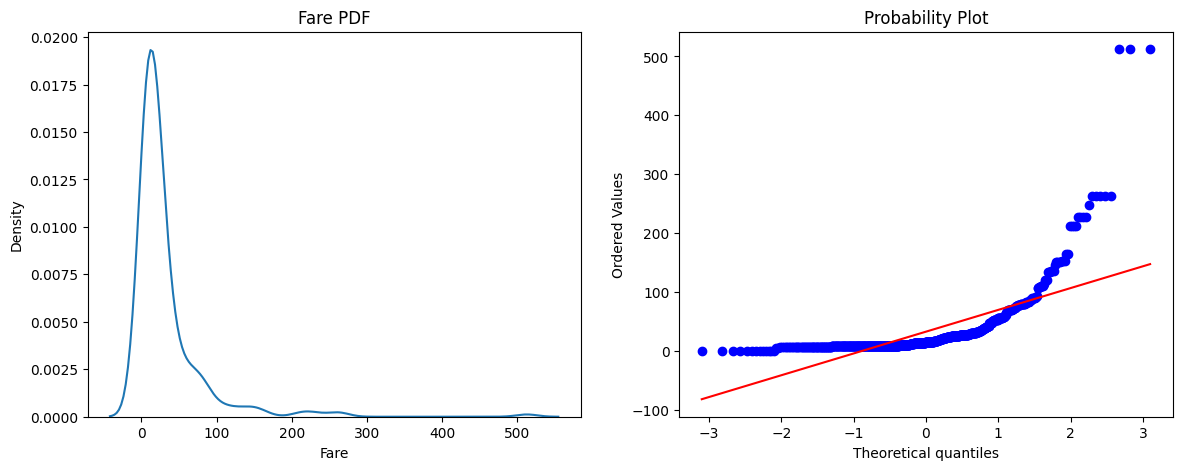

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.title("Fare PDF")
sns.kdeplot(x_train['Fare'])

plt.subplot(1,2,2)
plt.title("Fare QQ Plot")
stats.probplot(x_train['Fare'],dist='norm',plot=plt)

plt.show()

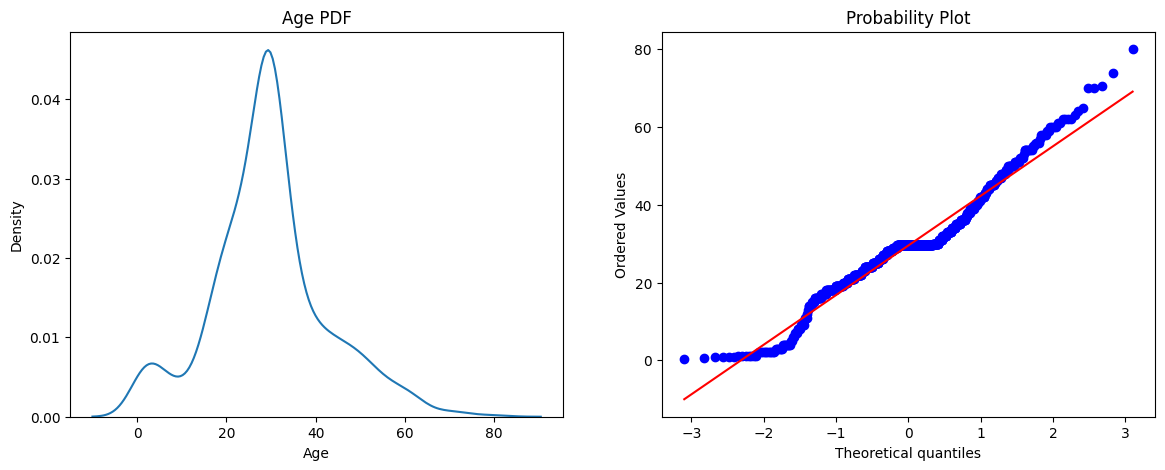

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.title("Age PDF")
sns.kdeplot(x_train['Age'])

plt.subplot(1,2,2)
plt.title("Age QQ Plot")
stats.probplot(x_train['Age'],dist='norm',plot=plt)

plt.show()

Before Function Transformer Accuracy Of Models

In [ ]:
cl1 = LogisticRegression()
cl2 = DecisionTreeClassifier()

cl1.fit(x_train,y_train)
cl2.fit(x_train,y_train)

y_pred1 = cl1.predict(x_test)
y_pred2 = cl2.predict(x_test)

print(f"cl1:-{accuracy_score(y_test,y_pred1)}")
print(f"cl2:-{accuracy_score(y_test,y_pred2)}")

cl1:-0.6480446927374302
cl2:-0.6703910614525139


using Transformer

In [ ]:
trf = FunctionTransformer(np.log1p)

In [ ]:
x_train_transformed = trf.fit_transform(x_train)
x_test_transformed = trf.transform(x_test)

In [ ]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)

y_pred1 = clf1.predict(x_test_transformed)
y_pred2 = clf2.predict(x_test_transformed)

print(f"clf1:-{accuracy_score(y_test,y_pred1)}")
print(f"clf2:-{accuracy_score(y_test,y_pred2)}")

clf1:-0.6815642458100558
clf2:-0.664804469273743


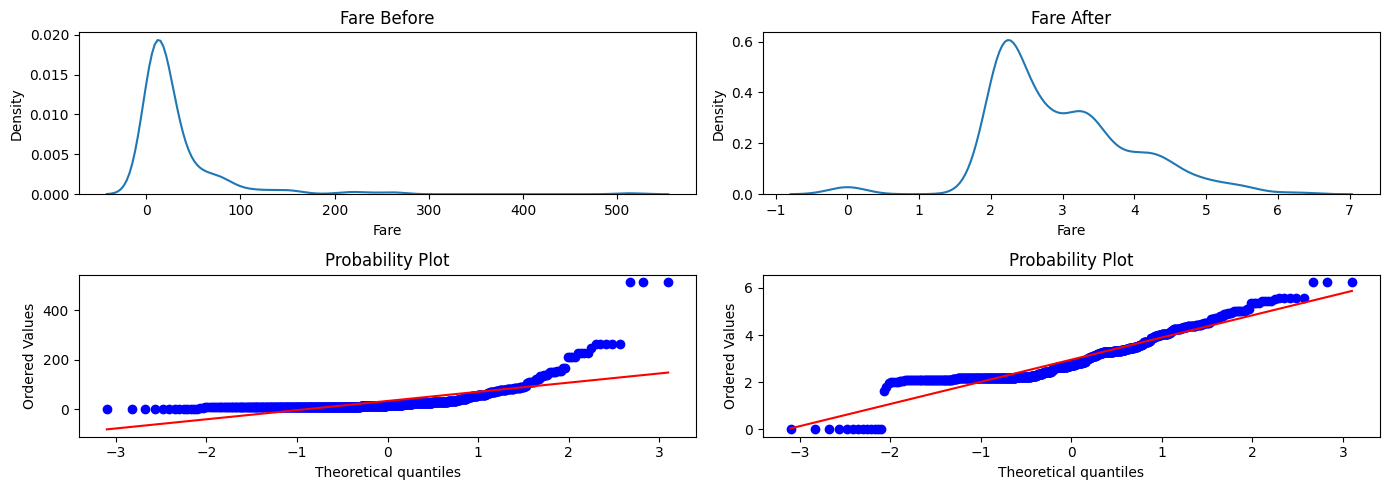

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(2,2,1)
plt.title("Fare Before")
sns.kdeplot(x_train['Fare'])

plt.subplot(2,2,3)
plt.title("Fare Before")
stats.probplot(x_train['Fare'],dist='norm',plot=plt)

plt.subplot(2,2,2)
plt.title("Fare After")
sns.kdeplot(x_train_transformed['Fare'])

plt.subplot(2,2,4)
plt.title("Fare After")
stats.probplot(x_train_transformed['Fare'],dist='norm',plot=plt)

plt.tight_layout()
plt.show()

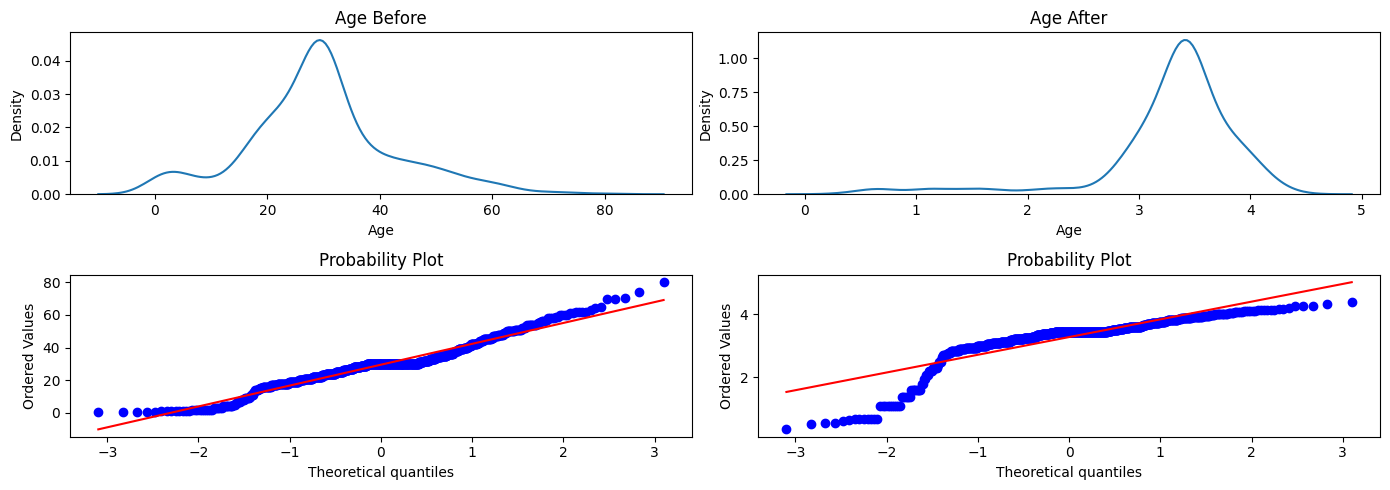

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(2,2,1)
plt.title("Age Before")
sns.kdeplot(x_train['Age'])

plt.subplot(2,2,3)
plt.title("Age Before")
stats.probplot(x_train['Age'],dist='norm',plot=plt)

plt.subplot(2,2,2)
plt.title("Age After")
sns.kdeplot(x_train_transformed['Age'])

plt.subplot(2,2,4)
plt.title("Age After")
stats.probplot(x_train_transformed['Age'],dist='norm',plot=plt)

plt.tight_layout()
plt.show()

Our Age data become right skewed after applying Function Transformer so we passthrough the age column using ColumnTransformer

In [ ]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

x_train_transformed2 = trf2.fit_transform(x_train)
x_test_transformed2 = trf2.transform(x_test)

In [ ]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(x_train_transformed2,y_train)
clf2.fit(x_train_transformed2,y_train)

y_pred1 = clf1.predict(x_test_transformed2)
y_pred2 = clf2.predict(x_test_transformed2)

print(f"clf1:-{accuracy_score(y_test,y_pred1)}")
print(f"clf2:-{accuracy_score(y_test,y_pred2)}")

clf1:-0.6703910614525139
clf2:-0.6703910614525139


Function to apply ,mmore transformeres

In [ ]:
def apply_transform(transform):
    x = data[['Age','Fare']]
    y = data['Survived']

    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')

    X_trans = trf.fit_transform(x)

    clf = LogisticRegression()

    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(x['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()


Accuracy 0.6195131086142323


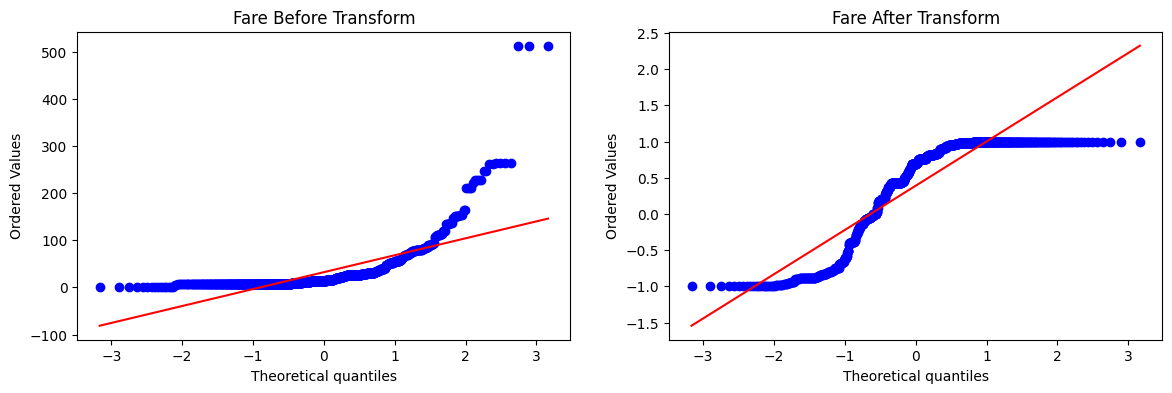

In [ ]:
apply_transform(np.sin)